# Cont & Kukanov (2017): numerical experiments

*Optimal order placement in limit order markets*, Rama Cont & Arseniy Kukanov.
*arXiv:1210.1625v4.*

This notebook implements the SGD algorithm from Section 4 and runs some experiments.
A few implementation choices differ from the paper and are noted where relevant.

## Setup

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import poisson as pois_dist

RNG = np.random.default_rng(42)

# -- style ----------------
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  True,
    "axes.spines.bottom": True,
    "axes.grid":   True,
    "grid.alpha":  0.25,
    "grid.color":  "#aaaaaa",
    "grid.linewidth": 0.6,
    "font.family": "monospace",
    "font.size":   10,
    "axes.titlesize":  11,
    "axes.titleweight": "bold",
    "axes.labelsize":  10,
    "legend.fontsize":  9,
    "legend.framealpha": 0.85,
    "lines.linewidth": 1.8,
    "axes.prop_cycle": plt.cycler(color=[
        "#2E86AB", "#E84855", "#3BB273", "#F18F01",
        "#9B5DE5", "#F15BB5", "#00BBF9",
    ]),
})
print("ready.")

ready.


## Core model

Fill on venue $k$ under FIFO priority:
$$F_k(L_k,\,\xi_k) = \min\!\left((\xi_k - Q_k)^+,\; L_k\right)$$

Cost function (Definition 1 of the paper):
$$v(X,\xi)
= \underbrace{(h+f)M}_{\text{MO cost}}
- \sum_k(h+r_k)F_k
+ \underbrace{\theta(M+\textstyle\sum_k L_k+(S-A)^+)}_{\text{impact}}
+ \lambda_u(S-A)^+
+ \lambda_o(A-S)^+$$


In [3]:
def fill_vec(L, Q, xi):
    return np.minimum(np.maximum(xi - Q, 0.0), L)

def executed_vec(X, xi_mat, p):
    M, Ls, Q = X[0], X[1:], p["Q"]
    return M + sum(fill_vec(Ls[k], Q[k], xi_mat[:, k]) for k in range(len(Ls)))

def cost_vec(X, xi_mat, p):
    h, f, th = p["h"], p["f"], p["theta"]
    lu, lo, r, S, Q = p["lam_u"], p["lam_o"], p["r"], p["S"], p["Q"]
    K = len(Q); M, Ls = X[0], X[1:]
    A = executed_vec(X, xi_mat, p)
    c  = (h + f) * M
    c -= sum((h + r[k]) * fill_vec(Ls[k], Q[k], xi_mat[:, k]) for k in range(K))
    c += th * (M + Ls.sum() + np.maximum(S - A, 0))
    c += lu * np.maximum(S - A, 0)
    c += lo * np.maximum(A - S, 0)
    return c

def mean_cost(X, xi_eval, p):
    return cost_vec(X, xi_eval, p).mean()

def grad_single(X, xi, p):
    h, f, th = p["h"], p["f"], p["theta"]
    lu, lo, r, S, Q = p["lam_u"], p["lam_o"], p["r"], p["S"], p["Q"]
    K = len(Q); M, Ls = X[0], X[1:]
    A = M + sum(max(xi[k]-Q[k],0) - max(xi[k]-Q[k]-Ls[k],0) for k in range(K))
    u, o = float(A < S), float(A > S)
    g = np.empty(K+1)
    g[0] = h + f + th - (lu+th)*u + lo*o
    for k in range(K):
        ft = float(xi[k] > Q[k] + Ls[k])
        g[1+k] = th + ft*(-(h+r[k]) - (lu+th)*u + lo*o)
    return g

### SGD optimisers

**Note on the paper's step size.** The formula in section 4 yields $\gamma \approx 57$
for the baseline parameters, which is ~4× above the stability threshold $1/L_{\text{lip}}$.
Starting from $(M,L)=(S,0)$ this causes the iterate to oscillate on the boundary of $\mathcal{C}$.

I thus use two fixes here:
- for $K=1$: reparametrise as a 1-D problem over $M\in[0,S]$ with $L=S-M$ hard-enforced.  
  Step size: $\gamma = 1/L_{\text{lip}}$.
- for $K>1$: start at the equal-split interior point; step size $\gamma = S/(L_{\text{lip}}\sqrt{N})$.


In [4]:
def optimize_K1(p, N, xi_samples, return_path=False):
    """1-D SGD for K=1 (L = S-M enforced exactly)."""
    h, f, th = p["h"], p["f"], p["theta"]
    lu, lo, r = p["lam_u"], p["lam_o"], p["r"][0]
    S, Q = p["S"], p["Q"][0]
    gamma = 1.0 / (lu + h + r + th)
    M = S / 2.0; M_sum = 0.0; path = np.empty(N)
    for n in range(N):
        xi = xi_samples[n, 0]; L = S - M
        ft    = float(xi > Q + L)
        under = float(xi < Q + L)
        g = h + f + th + (h+r)*ft - (lu+th)*under
        M = np.clip(M - gamma*g, 0.0, S)
        M_sum += M; path[n] = M
    M_hat = M_sum / N
    X_hat = np.array([M_hat, S - M_hat])
    return (X_hat, path) if return_path else X_hat


def optimize_multi(p, N, xi_samples, X0=None, return_path=False):
    """General (K+1)-D SGD."""
    K = len(p["Q"]); S = p["S"]
    h, f, th, lu, lo, r = p["h"], p["f"], p["theta"], p["lam_u"], p["lam_o"], p["r"]
    L_lip = max(lu+lo+th, max(h+r[k]+lu+lo+th for k in range(K)))
    gamma = S / (L_lip * N**0.5)
    if X0 is None: X0 = np.full(K+1, S/(K+1))
    X = X0.copy().astype(float); X_sum = np.zeros(K+1)
    path = np.empty((N, K+1))
    for n in range(N):
        g = grad_single(X, xi_samples[n], p)
        Xn = X - gamma*g
        Xn[0] = np.clip(Xn[0], 0, S)
        for k in range(1, K+1): Xn[k] = np.clip(Xn[k], 0, S)
        X = Xn; X_sum += X; path[n] = X
    X_hat = X_sum / N
    return (X_hat, path) if return_path else X_hat


def draw_xi(K, N, mu_T=2200., alpha=0.6, rng=RNG):
    """Single-factor Poisson outflows (section 5.1)."""
    xi0 = rng.poisson(mu_T, size=N).astype(float)
    eps = rng.poisson(mu_T, size=(N, K)).astype(float)
    return alpha * xi0[:, None] + (1-alpha) * eps


def make_params(K, S, alpha=0.6, Q_val=2000., r_val=0.002,
                mu=2200., T=1., h=0.020, f=0.003,
                theta=0.0005, lam_u=0.05, lam_o=0.05):
    return dict(K=K, S=float(S), Q=np.full(K, Q_val), r=np.full(K, r_val),
                h=h, f=f, theta=theta, lam_u=lam_u, lam_o=lam_o,
                mu=mu, T=T, alpha=alpha)

---
## Experiment 1: validation ($K = 1$)

For $K=1$, proposition 3 of the paper gives:

$$L^* = F^{-1}\!\left(\frac{2h+f+r}{\lambda_u+h+r+\theta}\right) - Q, \qquad M^* = S - L^*.$$
We check that the SGD average iterate converges to this, and that the error decays as $O(1/\sqrt{N})$.


closed-form : M* = 786,  L* = 214
SGD (N=50000): M* ≈ 782.9,  L* ≈ 217.1
error : 3.1 shares  (0.4%)
runtime : 0.3s


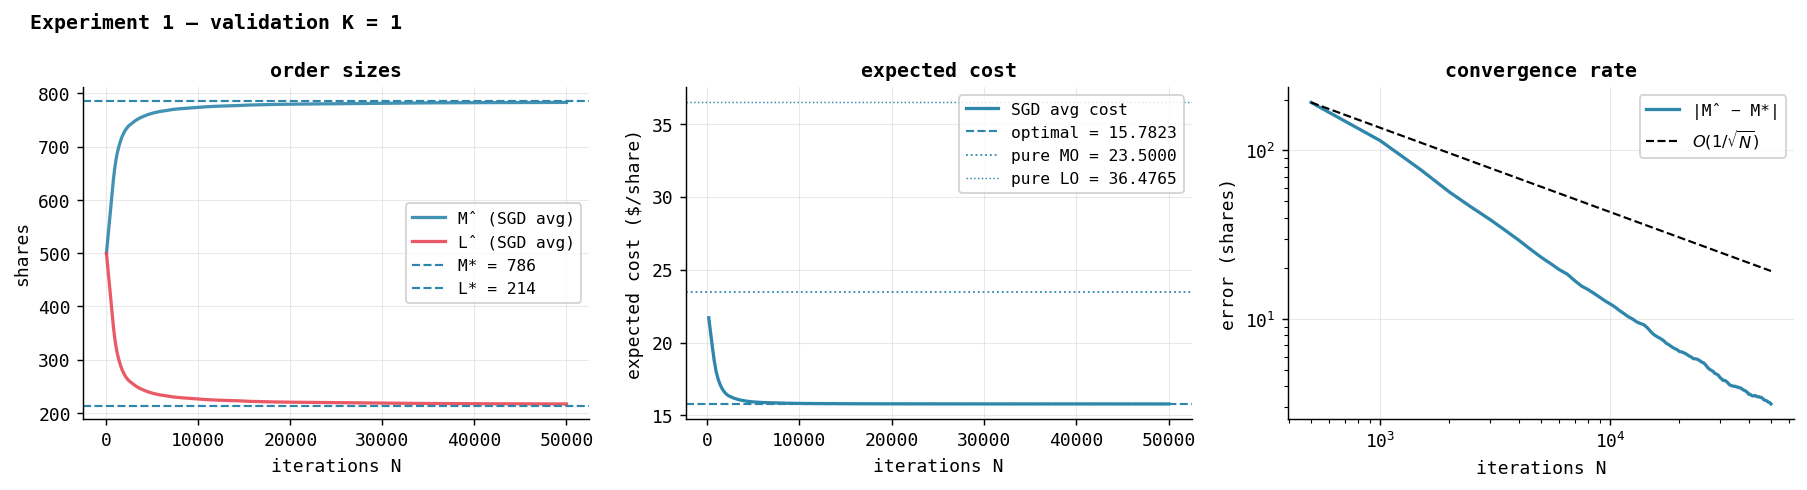

In [11]:
t0 = time.time()

p1 = make_params(K=1, S=1000.0)
mu_T = p1["mu"] * p1["T"]

# closed-form
h, f, r_, th_ = p1["h"], p1["f"], p1["r"][0], p1["theta"]
lu_, Q_, S_ = p1["lam_u"], p1["Q"][0], p1["S"]
q_lev = (2*h + f + r_) / (lu_ + h + r_ + th_)
L_cf  = float(max(pois_dist.ppf(q_lev, mu_T) - Q_, 0))
M_cf  = S_ - L_cf

N_sgd = 50_000
xi_tr = RNG.poisson(mu_T, size=(N_sgd, 1)).astype(float)
X_hat, path_M = optimize_K1(p1, N_sgd, xi_tr, return_path=True)

xi_ev  = RNG.poisson(mu_T, size=(20_000, 1)).astype(float)
running_M = np.cumsum(path_M) / np.arange(1, N_sgd+1)
running_L = S_ - running_M
error_M   = np.abs(running_M - M_cf)

step = 200
Ns_plot = np.arange(step, N_sgd+1, step)
run_costs = []
for n in Ns_plot:
    run_costs.append(mean_cost(np.array([running_M[n-1], running_L[n-1]]), xi_ev, p1))

cost_cf = mean_cost(np.array([M_cf, L_cf]),  xi_ev, p1)
cost_MO = mean_cost(np.array([S_, 0.]),      xi_ev, p1)
cost_LO = mean_cost(np.array([0., S_]),      xi_ev, p1)

print(f"closed-form : M* = {M_cf:.0f},  L* = {L_cf:.0f}")
print(f"SGD (N={N_sgd}): M* ≈ {X_hat[0]:.1f},  L* ≈ {X_hat[1]:.1f}")
print(f"error : {abs(X_hat[0]-M_cf):.1f} shares  ({100*abs(X_hat[0]-M_cf)/M_cf:.1f}%)")
print(f"runtime : {time.time()-t0:.1f}s")

# -- plot ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
fig.suptitle("Experiment 1 — validation K = 1", x=0.02, ha="left", fontsize=11, fontweight="bold")

ax = axes[0]
ax.plot(running_M, label="M̂ (SGD avg)", alpha=0.9)
ax.plot(running_L, label="L̂ (SGD avg)", alpha=0.9)
ax.axhline(M_cf, ls="--", lw=1.2, label=f"M* = {M_cf:.0f}")
ax.axhline(L_cf, ls="--", lw=1.2, label=f"L* = {L_cf:.0f}")
ax.set_xlabel("iterations N"); ax.set_ylabel("shares")
ax.set_title("order sizes"); ax.legend()

ax = axes[1]
ax.plot(Ns_plot, run_costs, label="SGD avg cost")
ax.axhline(cost_cf, ls="--", lw=1.2, label=f"optimal = {cost_cf:.4f}")
ax.axhline(cost_MO, ls=":",  lw=1.0, label=f"pure MO = {cost_MO:.4f}")
ax.axhline(cost_LO, ls=":",  lw=0.8, label=f"pure LO = {cost_LO:.4f}")
ax.set_xlabel("iterations N"); ax.set_ylabel("expected cost ($/share)")
ax.set_title("expected cost"); ax.legend()

ax = axes[2]
Ns_err = np.arange(500, N_sgd+1, 500)
ax.loglog(Ns_err, error_M[Ns_err-1], label="|M̂ − M*|")
ref = error_M[499] * (500 / Ns_err)**0.5
ax.loglog(Ns_err, ref, "k--", lw=1.2, label=r"$O(1/\sqrt{N})$")
ax.set_xlabel("iterations N"); ax.set_ylabel("error (shares)")
ax.set_title(r"convergence rate"); ax.legend()

plt.tight_layout()
plt.savefig("exp1_validation.png", bbox_inches="tight")
plt.show()


---
## Experiment 2: effect of $K$

As $K$ grows: the market order fraction $M^*/S$ decreases (more passive capacity),
and the total submitted quantity $M^* + \sum L_k^*$ can exceed $S$ (overbooking).


runtime : 8.9s


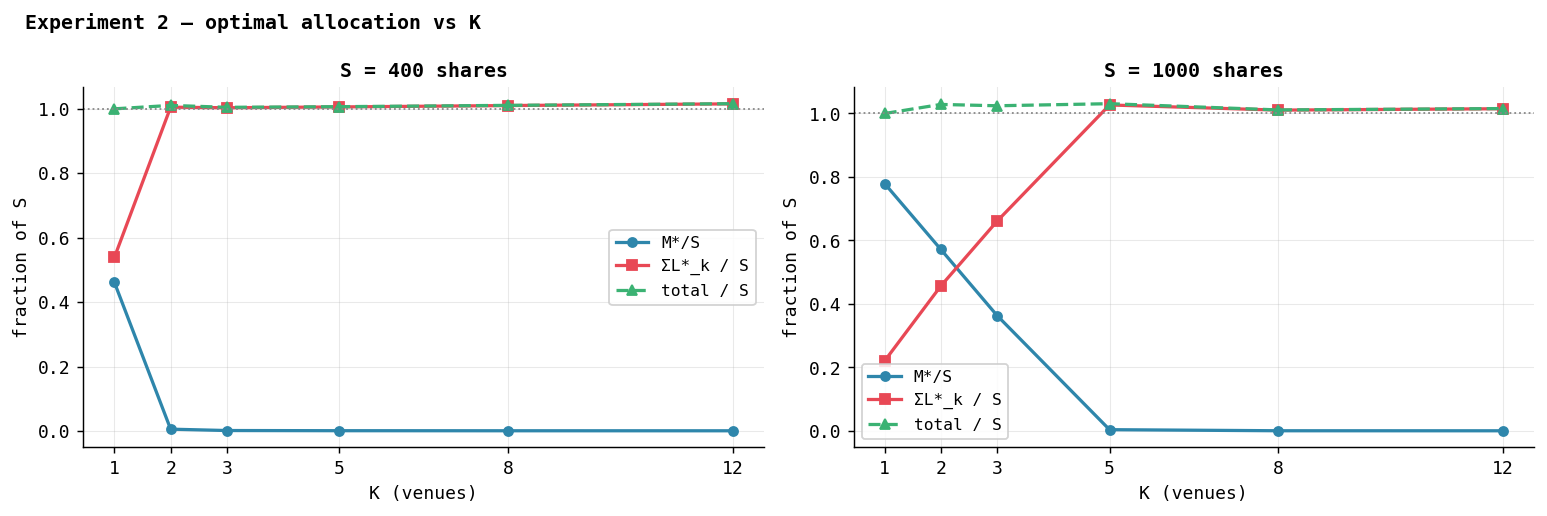

In [12]:
t0 = time.time()

K_values = [1, 2, 3, 5, 8, 12]
S_values = [400, 1000]
N_opt    = 20_000
results_K = {S: {} for S in S_values}

for S in S_values:
    for K in K_values:
        p = make_params(K, S)
        if K == 1:
            xi = RNG.poisson(p["mu"]*p["T"], size=(N_opt, 1)).astype(float)
            X  = optimize_K1(p, N_opt, xi)
        else:
            xi = draw_xi(K, N_opt, alpha=p["alpha"])
            X  = optimize_multi(p, N_opt, xi)
        results_K[S][K] = X

print(f"runtime : {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Experiment 2 — optimal allocation vs K", x=0.02, ha="left", fontsize=11, fontweight="bold")

for idx, S in enumerate(S_values):
    ax = axes[idx]
    MO  = [results_K[S][K][0]   / S for K in K_values]
    LO  = [results_K[S][K][1:].sum() / S for K in K_values]
    tot = [results_K[S][K].sum() / S for K in K_values]
    ax.plot(K_values, MO,  "o-", ms=5, label="M*/S")
    ax.plot(K_values, LO,  "s-", ms=5, label="ΣL*_k / S")
    ax.plot(K_values, tot, "^--",ms=5, label="total / S")
    ax.axhline(1.0, color="#888", ls=":", lw=1)
    ax.set_xlabel("K (venues)"); ax.set_ylabel("fraction of S")
    ax.set_title(f"S = {S} shares")
    ax.set_xticks(K_values); ax.legend()

plt.tight_layout()
plt.savefig("exp2_K_effect.png", bbox_inches="tight")
plt.show()

---
## Experiment 3: inter-venue correlation

The single-factor model $\xi_k = \alpha\,\xi_0 + (1-\alpha)\,\varepsilon_k$ lets us dial
correlation from fully independent ($\alpha=0$) to perfectly correlated ($\alpha=1$).

At $\alpha=1$ all venues fill or fail together: posting on multiple venues gives no extra
fill probability, so overbooking collapses. This is a limiting case the paper doesn't analyse explicitly.


overbooking at α=0.0 : 1.237×S
overbooking at α=1.0 : 1.006×S
runtime : 4.3s


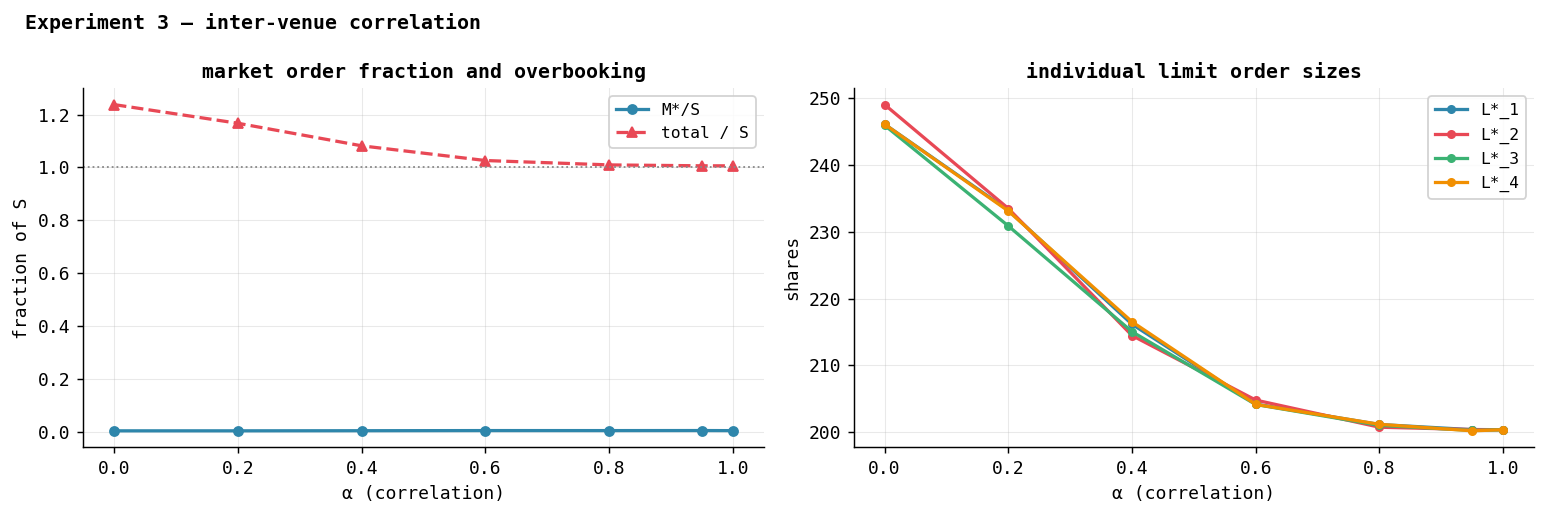

In [13]:
t0 = time.time()

alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95, 1.0]
K_corr, S_corr, N_corr = 4, 800, 20_000
results_corr = {}

for alpha in alpha_values:
    p   = make_params(K_corr, S_corr, alpha=alpha)
    xi  = draw_xi(K_corr, N_corr, alpha=alpha)
    results_corr[alpha] = optimize_multi(p, N_corr, xi)

print(f"overbooking at α=0.0 : {results_corr[0.0].sum()/S_corr:.3f}×S")
print(f"overbooking at α=1.0 : {results_corr[1.0].sum()/S_corr:.3f}×S")
print(f"runtime : {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Experiment 3 — inter-venue correlation", x=0.02, ha="left", fontsize=11, fontweight="bold")

ax = axes[0]
ax.plot(alpha_values, [results_corr[a][0]/S_corr  for a in alpha_values], "o-", ms=5, label="M*/S")
ax.plot(alpha_values, [results_corr[a].sum()/S_corr for a in alpha_values], "^--",ms=5, label="total / S")
ax.axhline(1.0, color="#888", ls=":", lw=1)
ax.set_xlabel("α (correlation)"); ax.set_ylabel("fraction of S")
ax.set_title("market order fraction and overbooking"); ax.legend()

ax = axes[1]
for k_idx in range(K_corr):
    ax.plot(alpha_values, [results_corr[a][1+k_idx] for a in alpha_values],
            "o-", ms=4, label=f"L*_{k_idx+1}")
ax.set_xlabel("α (correlation)"); ax.set_ylabel("shares")
ax.set_title("individual limit order sizes"); ax.legend()

plt.tight_layout()
plt.savefig("exp3_correlation.png", bbox_inches="tight")
plt.show()


---
## Experiment 4: tail heaviness

Proposition 3 says $L^*$ depends on the *quantile* of $F$, not its mean.
Two distributions with the same mean but different tails should give different allocations,
heavier tails mean large outflows (the ones that fill deep limit orders) are more probable.


L* by distribution (same mean):
  exponential              : L* = 239
  pareto α =   2.0           : L* = 31
  pareto α =   3.0           : L* = 43
  pareto α =   5.0           : L* = 78
  pareto α =  10.0           : L* = 158
  pareto α =  50.0           : L* = 226
runtime : 0.8s


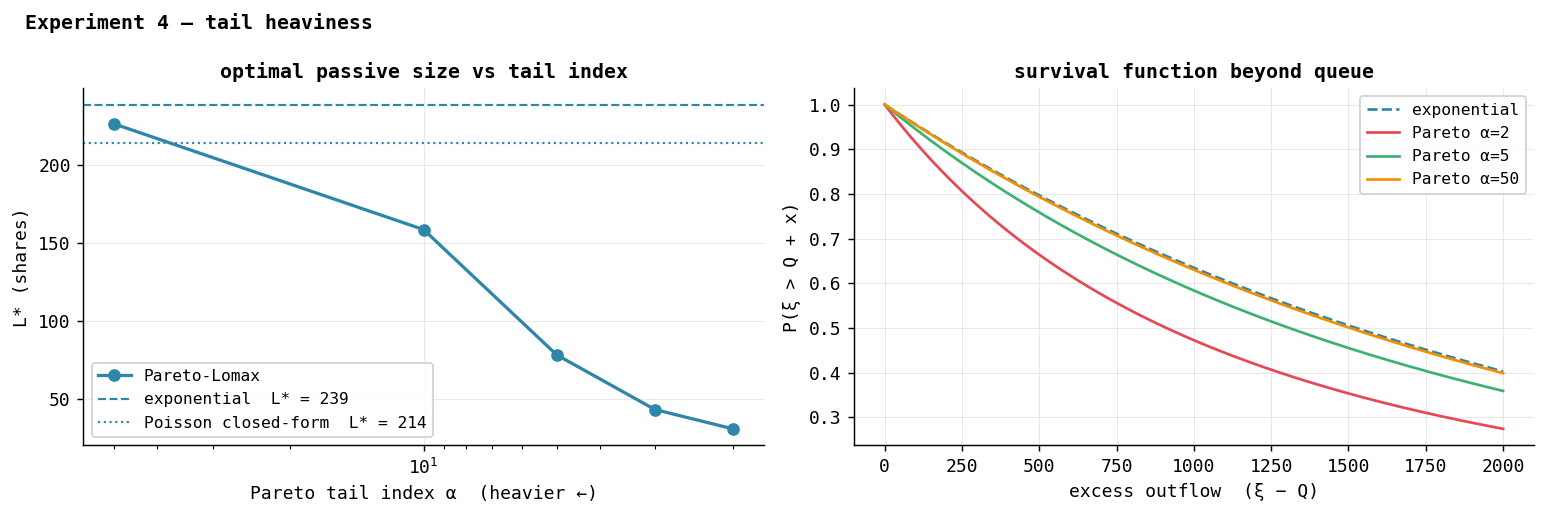

In [14]:
t0 = time.time()

p_tail = make_params(K=1, S=1000., Q_val=2000.)
N_tail = 30_000

def draw_exponential(N, mu_T, rng=RNG):
    return rng.exponential(scale=mu_T, size=(N, 1))

def draw_pareto_lomax(N, mu_T, alpha, rng=RNG):
    """Lomax with mean = mu_T: scale = mu_T*(alpha-1)."""
    scale = mu_T * (alpha - 1)
    U = rng.uniform(0, 1, size=(N, 1))
    return scale * (U**(-1./alpha) - 1)

mu_T_tail  = 2200.
tail_alphas = [2.0, 3.0, 5.0, 10.0, 50.0]

X_exp = optimize_K1(p_tail, N_tail, draw_exponential(N_tail, mu_T_tail))
results_tail = {}
for a in tail_alphas:
    results_tail[a] = optimize_K1(p_tail, N_tail, draw_pareto_lomax(N_tail, mu_T_tail, a))

print("L* by distribution (same mean):")
print(f"  exponential              : L* = {X_exp[1]:.0f}")
for a in tail_alphas:
    print(f"  pareto α = {a:5.1f}           : L* = {results_tail[a][1]:.0f}")
print(f"runtime : {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Experiment 4 — tail heaviness", x=0.02, ha="left", fontsize=11, fontweight="bold")

ax = axes[0]
L_vals = [results_tail[a][1] for a in tail_alphas]
ax.semilogx(tail_alphas, L_vals, "o-", ms=6, label="Pareto-Lomax")
ax.axhline(X_exp[1], ls="--", lw=1.2, label=f"exponential  L* = {X_exp[1]:.0f}")
q_lev = (2*p_tail["h"]+p_tail["f"]+p_tail["r"][0]) / (p_tail["lam_u"]+p_tail["h"]+p_tail["r"][0]+p_tail["theta"])
L_pois = max(pois_dist.ppf(q_lev, mu_T_tail) - p_tail["Q"][0], 0)
ax.axhline(L_pois, ls=":", lw=1.2, label=f"Poisson closed-form  L* = {L_pois:.0f}")
ax.invert_xaxis()
ax.set_xlabel("Pareto tail index α  (heavier ←)"); ax.set_ylabel("L* (shares)")
ax.set_title("optimal passive size vs tail index"); ax.legend()

ax = axes[1]
x_exc = np.linspace(0, 2000, 400)
ax.plot(x_exc, np.exp(-x_exc/mu_T_tail), ls="--", lw=1.5, label="exponential")
for a in [2., 5., 50.]:
    scale = mu_T_tail*(a-1)
    ax.plot(x_exc, (1 + x_exc/scale)**(-a), lw=1.5, label=f"Pareto α={a:.0f}")
ax.set_xlabel("excess outflow  (ξ − Q)"); ax.set_ylabel("P(ξ > Q + x)")
ax.set_title("survival function beyond queue"); ax.legend()

plt.tight_layout()
plt.savefig("exp4_tails.png", bbox_inches="tight")
plt.show()


---
## Experiment 5: threshold $K^*(S)$

The paper says $M^*/S$ decreases with $K$ but gives no closed form.
A natural breakeven is:

$$K^*(S) = \frac{S}{\mathbb{E}[(\xi_k - Q_k)^+]}$$

We check this numerically and see whether the curves collapse when plotted against $K/K^*(S)$.


E[(ξ−Q)+] = 200.00 shares
S =    400  →  K*(S) predicted =   2.0,  numerical = 2
S =    800  →  K*(S) predicted =   4.0,  numerical = 4
S =   1500  →  K*(S) predicted =   7.5,  numerical = 7
S =   3000  →  K*(S) predicted =  15.0,  numerical = 14
S =   6000  →  K*(S) predicted =  30.0,  numerical = 27
S =  10000  →  K*(S) predicted =  50.0,  numerical = >30
runtime : 132.1s


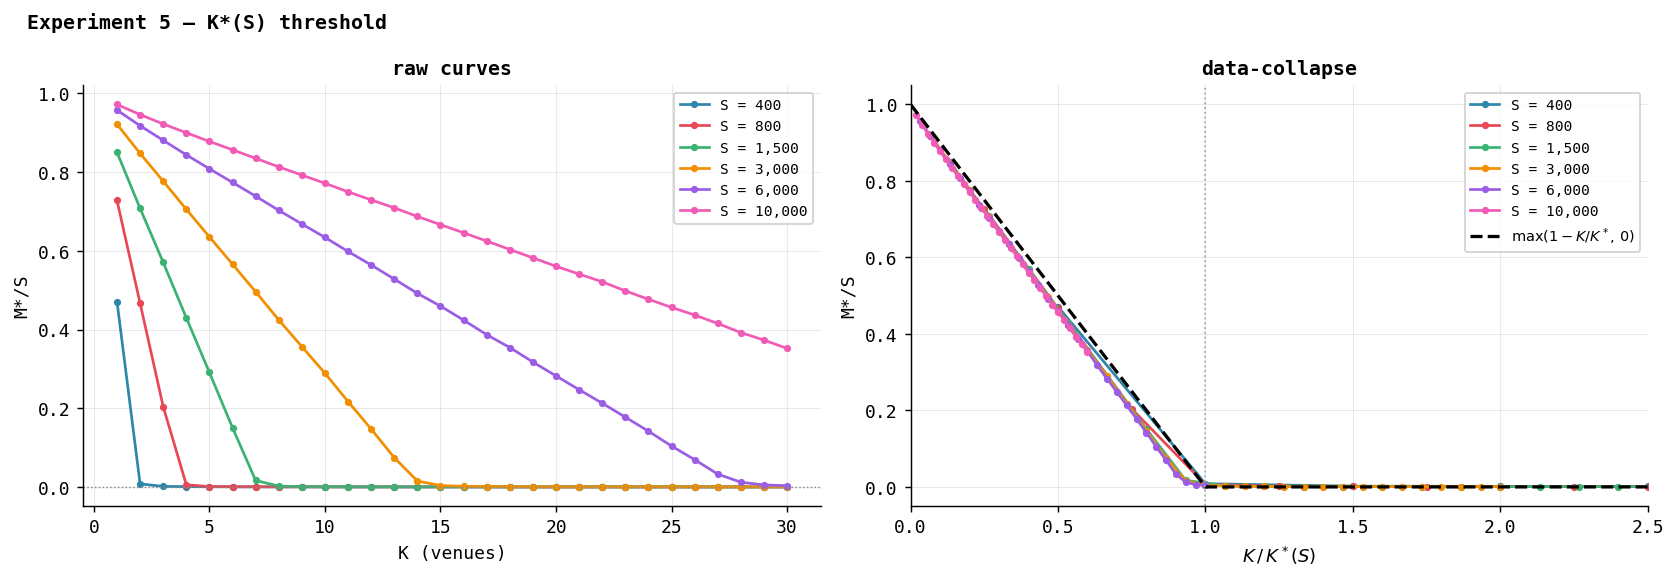


linear fit quality (MAE vs max(1-K/K*,0)):
       S    K*(S)       MAE    max err
     400      2.0    0.0020     0.0288
     800      4.0    0.0043     0.0456
    1500      7.5    0.0090     0.0494
    3000     15.0    0.0182     0.0584
    6000     30.0    0.0390     0.0668
   10000     50.0    0.0333     0.0478


In [15]:
t0 = time.time()

xs = np.arange(0, 20_000)
E_exc = (np.maximum(xs - 2000., 0) * pois_dist.pmf(xs, 2200.)).sum()
print(f"E[(ξ−Q)+] = {E_exc:.2f} shares")

S_grid = [400, 800, 1500, 3000, 6000, 10000]
K_grid = list(range(1, 31))
N_grid = 8_000
MO_grid = {S: [] for S in S_grid}

for S in S_grid:
    for K in K_grid:
        p  = make_params(K, S)
        xi = draw_xi(K, N_grid, alpha=0.6)
        X  = optimize_multi(p, N_grid, xi)
        MO_grid[S].append(float(X[0]) / S)
    Kstar_num  = next((K for K, v in zip(K_grid, MO_grid[S]) if v < 0.05), ">30")
    Kstar_pred = S / E_exc
    print(f"S = {S:6.0f}  →  K*(S) predicted = {Kstar_pred:5.1f},  numerical = {Kstar_num}")

print(f"runtime : {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Experiment 5 — K*(S) threshold", x=0.02, ha="left", fontsize=11, fontweight="bold")

ax = axes[0]
for S in S_grid:
    ax.plot(K_grid, MO_grid[S], "o-", ms=3, lw=1.5, label=f"S = {S:,}")
ax.axhline(0, color="#888", lw=0.8, ls=":")
ax.set_xlabel("K (venues)"); ax.set_ylabel("M*/S")
ax.set_title("raw curves"); ax.legend(fontsize=8)

ax = axes[1]
K_norm = np.linspace(0, 2.5, 300)
for S in S_grid:
    Kstar = S / E_exc
    K_rel = [K / Kstar for K in K_grid]
    ax.plot(K_rel, MO_grid[S], "o-", ms=3, lw=1.5, label=f"S = {S:,}")
ax.plot(K_norm, np.maximum(1 - K_norm, 0), "k--", lw=1.8,
        label=r"$\max(1 - K/K^*,\,0)$")
ax.axvline(1.0, color="#aaa", ls=":", lw=1)
ax.set_xlabel(r"$K\,/\,K^*(S)$"); ax.set_ylabel("M*/S")
ax.set_title("data-collapse"); ax.legend(fontsize=8)
ax.set_xlim(0, 2.5)

plt.tight_layout()
plt.savefig("exp5_asymptotic.png", bbox_inches="tight")
plt.show()

print(f"\nlinear fit quality (MAE vs max(1-K/K*,0)):")
print(f"{'S':>8}   {'K*(S)':>6}   {'MAE':>7}   {'max err':>8}")
for S in S_grid:
    Kstar = S / E_exc
    errs = [abs(v - max(1 - K/Kstar, 0)) for K, v in zip(K_grid, MO_grid[S])]
    print(f"{S:8.0f}   {Kstar:6.1f}   {np.mean(errs):7.4f}   {np.max(errs):8.4f}")


---
## Summary

| experiment | finding |
|------|---------|
| 1. validation | SGD converges to the closed-form $M^*=786$, $L^*=214$ at rate $O(1/\sqrt{N})$. The paper's step-size formula is 4× too large for our initialization; a Lipschitz-based choice resolves the boundary oscillation. |
| 2. effect of K | Market order fraction decreases monotonically with $K$; overbooking grows with $K$. Both effects are stronger for large $S$. |
| 3. correlation | As $\alpha\to 1$, overbooking collapses to zero: the diversification benefit of multi-venue posting indeed vanishes when fills are perfectly correlated. |
| 4. tail heaviness | Heavier-tailed outflows justify larger passive orders. Two distributions with the same mean but different tails produce materially different $L^*$, confirming that the relevant object is the *quantile* of $F$, not its mean. |
| 5. threshold K*(S) | The critical venue count satisfies $K^*(S) \approx S/\mathbb{E}[(\xi-Q)^+]$. When plotted against $K/K^*(S)$, all curves collapse onto the linear envelope $\max(1-K/K^*,\,0)$ ; and this "scaling law" is not explicitely discussed in the paper. |
